# 🚀 03_Advanced Practice: 실제 모델 시각화 및 최신 트렌드 최적화 과제

이 노트북은 두 파트로 나뉩니다.
- **Part 1 (XAI 시각화)**: 실제 오픈소스 모델(BERT)을 불러와 내부 어텐션 맵을 들여다보며, 모델이 문맥을 어떻게 이해하는지 시각적 인사이트를 얻습니다.
- **Part 2 (최신 최적화 과제)**: 모델이 거대화될 때 발생하는 메모리와 속도 병목을 해결하기 위한 최신 트렌드(KV Caching, FlashAttention)를 더미 텐서를 활용해 직접 구현해보는 개발자 실습입니다.

--- 
## 🔍 Part 1. 사전학습 모델의 어텐션 시각화 (XAI 인사이트)
자연어 처리 모델이 엉뚱한 대답을 할 때, 기획자와 개발자는 모델이 어느 단어에 꽂혀서 잘못된 판단을 했는지 파악해야 합니다. 어텐션 가중치 추출은 딥러닝의 블랙박스를 열어보는 가장 확실한 설명가능한 AI(XAI) 기법입니다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

import transformers
transformers.logging.set_verbosity_error()

In [2]:
import warnings
warnings.filterwarnings('ignore')
from transformers import logging
logging.set_verbosity_error()

# !pip install transformers torch seaborn matplotlib bertviz
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import os

if os.name == 'nt': plt.rc('font', family='Malgun Gothic') # 윈도우 한글 폰트

# 한국어 BERT 로드 (어텐션 출력 옵션 True)
model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

# 테스트 문장: 대명사 추론
text = "동물이 길을 건너지 않았다. 왜냐하면 그것은 너무 피곤했기 때문이다."
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions
print(f"추출된 레이어 수: {len(attentions)}, 크기: {attentions[0].shape} (Batch, Head, Seq, Seq)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

추출된 레이어 수: 12, 크기: torch.Size([1, 12, 22, 22]) (Batch, Head, Seq, Seq)


### 1.1 여러 Head의 동시 비교 시각화 (Subplots)
트랜스포머는 여러 개의 Head를 가집니다. 각 Head가 완전히 다른 문법적/의미적 단어에 집중하는 것을 확인해 봅니다.

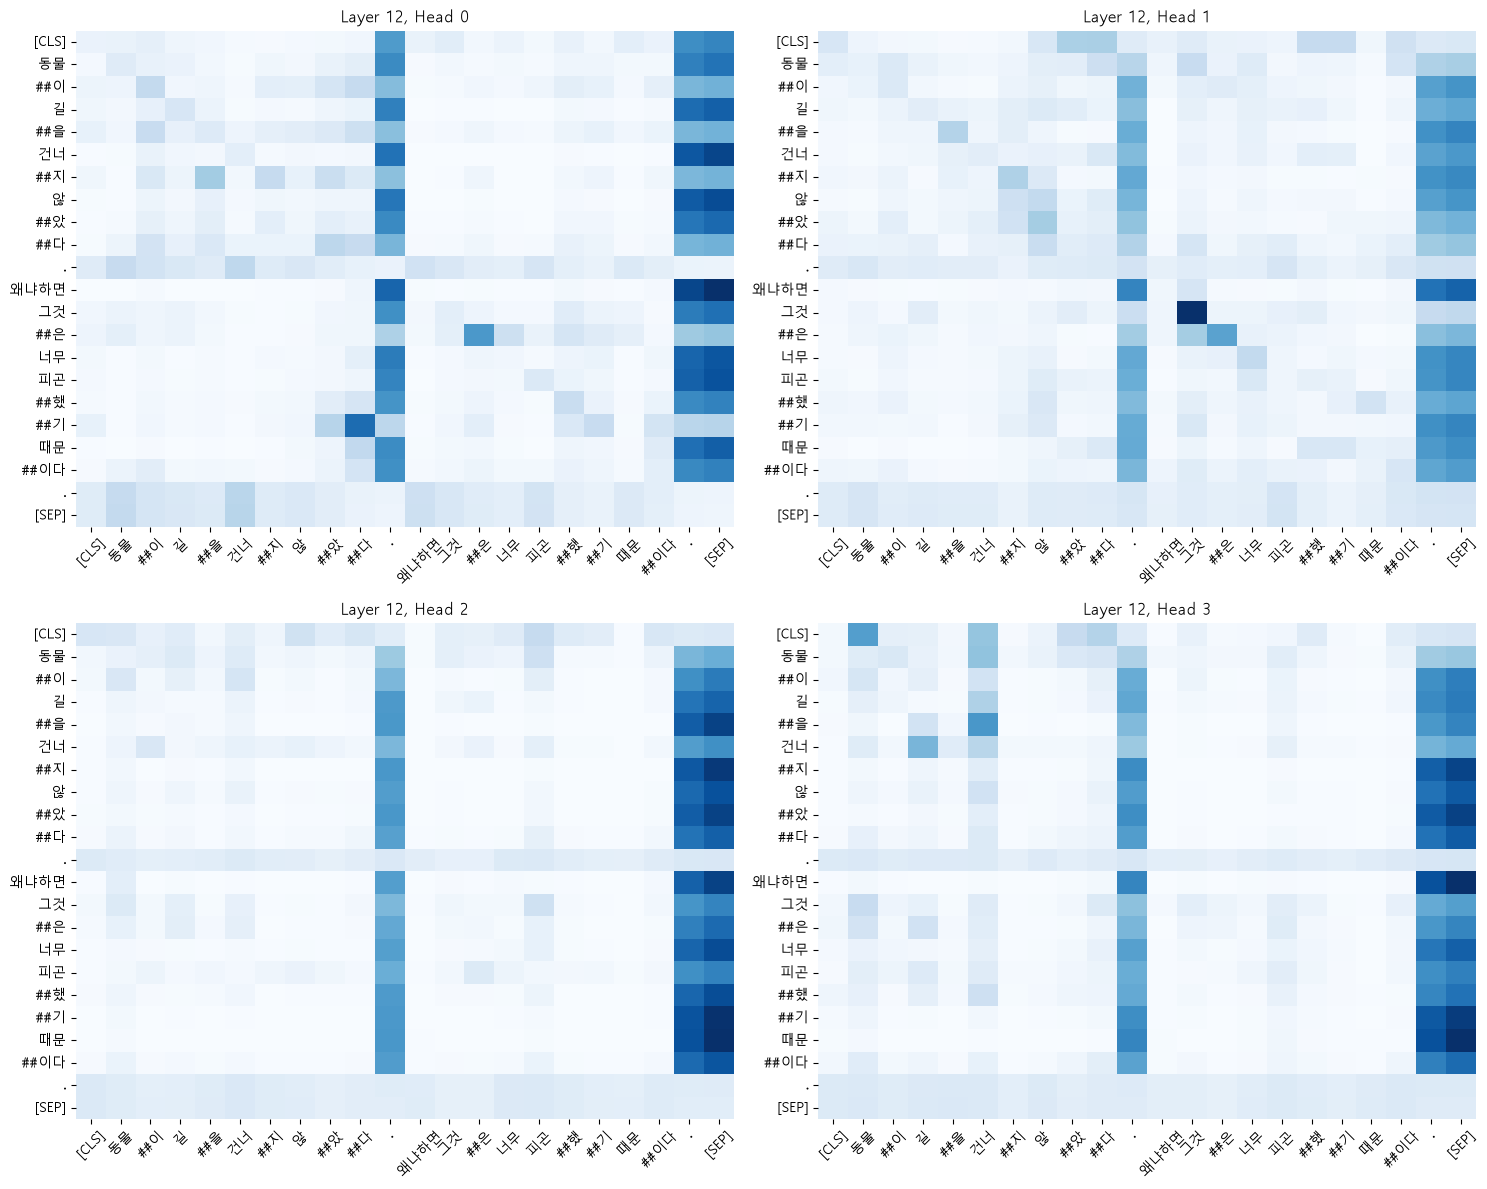

💡 [비즈니스 인사이트]: 특정 헤드는 '그것은'이라는 단어가 '동물'을 가리키는 것에 집중하고, 다른 헤드는 마침표(.)나 동사 구조에 집중합니다. 환각(Hallucination) 발생 시 이러한 시각화를 통해 프롬프트나 데이터의 문제를 진단할 수 있습니다.


In [3]:
layer_idx = -1 # 마지막 12번 레이어
heads_to_visualize = [0, 1, 2, 3]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, head_idx in enumerate(heads_to_visualize):
    attn_matrix = attentions[layer_idx][0, head_idx].numpy()
    sns.heatmap(attn_matrix, cmap="Blues", xticklabels=tokens, yticklabels=tokens, ax=axes[i], cbar=False)
    axes[i].set_title(f"Layer 12, Head {head_idx}")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print("💡 [비즈니스 인사이트]: 특정 헤드는 '그것은'이라는 단어가 '동물'을 가리키는 것에 집중하고, 다른 헤드는 마침표(.)나 동사 구조에 집중합니다. 환각(Hallucination) 발생 시 이러한 시각화를 통해 프롬프트나 데이터의 문제를 진단할 수 있습니다.")

### 1.2 `bertviz`를 이용한 Interactive 시각화
고정된 이미지가 아닌, 선으로 동적으로 연결되는 아름다운 툴을 사용해 봅니다. (※ 주피터 환경에서 마우스 오버가 가능합니다)

In [4]:
try:
    from bertviz import head_view
    # 아래 코드를 실행하면 인터랙티브 뷰어가 나타납니다. 상단의 Layer와 Head를 클릭해보세요!
    head_view(attentions, tokens)
except ImportError:
    print("bertviz가 설치되어 있지 않습니다. 위에서 !pip install bertviz 를 실행해주세요.")

<IPython.core.display.Javascript object>

--- 
## 🛠️ Part 2. 최신 트렌드 실무 과제 (Optimization 인사이트)
이제 위에서 본 거대한 행렬 연산을 실제 서비스(ChatGPT 등)에 올린다고 가정해봅시다.
글자를 생성할 때마다 저 거대한 연산을 처음부터 다시 하면 서버가 터집니다. 이를 극복하는 최신 기법을 **더미 텐서**로 가볍게 실습해 봅니다.

In [5]:
import time
import math
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 실습 디바이스: {device} (노트북 CPU에서도 매우 빠르게 동작합니다!)")

현재 실습 디바이스: cpu (노트북 CPU에서도 매우 빠르게 동작합니다!)


### 🎯 미션 1: KV Caching을 활용한 텍스트 생성 최적화
과거의 K, V 벡터를 `캐시(Cache)`에 보관해두고, **새로 등장한 토큰의 정보만 캐시에 이어붙이는** 로직을 완성하세요.

In [6]:
batch_size, num_heads, d_k = 1, 8, 16

# 과거 문맥 (이미 계산되어 저장된 3글자의 Cache)
seq_len_past = 3
cache_k = torch.randn(batch_size, num_heads, seq_len_past, d_k, device=device) 
cache_v = torch.randn(batch_size, num_heads, seq_len_past, d_k, device=device)

# 새로 생성된 단어 1개
new_q = torch.randn(batch_size, num_heads, 1, d_k, device=device)
new_k = torch.randn(batch_size, num_heads, 1, d_k, device=device)
new_v = torch.randn(batch_size, num_heads, 1, d_k, device=device)

# ==========================================
# [TODO] 기존 캐시(cache_k, cache_v)에 새로운 토큰(new_k, new_v)을 이어붙이세요. (torch.cat 활용, dim=2)
# ==========================================
updated_cache_k = None 
updated_cache_v = None 

# 테스트 코드
if updated_cache_k is not None:
    assert updated_cache_k.shape[2] == seq_len_past + 1
    scores = torch.matmul(new_q, updated_cache_k.transpose(-2, -1))
    print("✅ 성공! 단 1개의 Query 연산만으로 전체 문맥을 흡수했습니다. (KV Cache 완성)")
else:
    print("❌ 코드를 완성해주세요.")

❌ 코드를 완성해주세요.


### 🎯 미션 2: PyTorch 2.0 SDPA (FlashAttention) 체험
GPU의 느린 메모리를 적게 쓰고 빠른 캐시(SRAM)에서 연산을 끝내버리는 하드웨어 최적화 기법입니다. (CPU 환경에서도 수식 최적화가 적용됩니다.)

In [7]:
# 대규모 문서를 가정한 텐서 (길이 2000)
B, H, L, D = 1, 8, 2000, 64
q = torch.randn(B, H, L, D, device=device)
k = torch.randn(B, H, L, D, device=device)
v = torch.randn(B, H, L, D, device=device)

# 1. 수동 Attention 연산 (기존 방식)
start = time.time()
scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(D)
out_manual = torch.matmul(F.softmax(scores, dim=-1), v)
manual_time = time.time() - start

# ==========================================
# [TODO] PyTorch 내장 함수 F.scaled_dot_product_attention(q, k, v)를 사용하여 결과를 내보세요.
# ==========================================
start = time.time()

out_sdpa = None 

sdpa_time = time.time() - start

# 테스트 코드
if out_sdpa is not None:
    print(f"수동 Attention 시간: {manual_time:.5f} sec")
    print(f"SDPA 연산 시간    : {sdpa_time:.5f} sec")
    print(f"💡 SDPA가 약 {manual_time/sdpa_time:.1f}배 더 빠릅니다! (거대 모델 서비스의 필수 기술)")
else:
    print("❌ SDPA 코드를 완성해주세요.")

❌ SDPA 코드를 완성해주세요.
